# Problem2：Rank vs Percent 批量比较

本 Notebook 从头实现：对每个 season（使用主表与 exports 中的 fan_estimates 文件）比较两种合成规则——`rank`（名次之和）与 `percent`（份额之和），计算每季的 DiffRate、Spearman rho、Kendall tau，并在 notebook 中展示每季的 p^{(V)} vs p^{(J)} 散点图（不保存任何文件）。

使用说明：直接从上到下运行所有单元。

In [6]:
%matplotlib inline
import os, re, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau

sns.set(style='whitegrid')

# 路径 —— 如需调整，请修改下面两个变量
DATA_CSV = r"e:\\Documents\\Mathematical-Modelling\\2026_MCM_Problem_C_Data.csv"
EXPORT_DIR = r"e:\\Documents\\Mathematical-Modelling\\exports"

# 载入主表（含基础清洗）
df = pd.read_csv(DATA_CSV, na_values=['N/A', ''])
df['celebrity_name'] = df['celebrity_name'].astype(str).str.strip()
df['ballroom_partner'] = df['ballroom_partner'].astype(str).str.strip()

# --- 工具函数 ---
def simulate(panel, method):
    couples = panel['couple_key'].unique().tolist() if 'couple_key' in panel.columns else []
    active = set(couples)

    elim_week = {c: np.nan for c in couples}

    weeks_local = sorted(panel['week'].unique()) if 'week' in panel.columns and not panel.empty else []
    max_week = int(weeks_local[-1]) if weeks_local else 0
    for w in weeks_local:

        dfw = panel[(panel['week'] == w) & (panel['couple_key'].isin(active))].copy()

        if dfw.empty or len(active) <= 1:
            continue

        # ranks (名次：rJ/rV)，缺失视为最差（底）
        if 'J_total' in dfw.columns:
            dfw['rJ'] = dfw['J_total'].rank(ascending=False, method='dense', na_option='bottom')
        else:
            dfw['rJ'] = np.nan
        if 'pF_share' in dfw.columns:
            dfw['rV'] = dfw['pF_share'].rank(ascending=False, method='dense', na_option='bottom')
        else:
            dfw['rV'] = np.nan
        # 填充缺失名次为较大值（即最差）
        if dfw['rJ'].notna().any():
            rj_fill = dfw['rJ'].max() + 1
        else:
            rj_fill = len(dfw) + 1
        if dfw['rV'].notna().any():
            rv_fill = dfw['rV'].max() + 1
        else:
            rv_fill = len(dfw) + 1
        dfw['rJ'] = dfw['rJ'].fillna(rj_fill)
        dfw['rV'] = dfw['rV'].fillna(rv_fill)
        dfw['R'] = dfw['rJ'] + dfw['rV']
        # pJ / pV / P
        dfw['pJ'] = dfw['pJ_raw'] if 'pJ_raw' in dfw.columns else np.nan
        dfw['pV'] = dfw['pF_share'] if 'pF_share' in dfw.columns else np.nan
        dfw['P'] = dfw['pJ'].fillna(0) + dfw['pV'].fillna(0)
        # 选择被淘汰者
        if method == 'rank':
            if dfw['R'].notna().any():
                mx = dfw['R'].max()
                cand = dfw[dfw['R'] == mx].copy()
            else:
                cand = dfw.copy()
            if cand.empty:
                cand = dfw.copy()
            sort_keys = [k for k in ['pF_share','J_total'] if k in cand.columns]
            if sort_keys:
                cand = cand.sort_values(by=sort_keys, na_position='last')
            chosen = cand.iloc[0]['couple_key']
        else:
            # percent
            if dfw['P'].notna().any():
                mn = dfw['P'].min()
                cand = dfw[dfw['P'] == mn].copy()
            else:
                cand = dfw.copy()
            if cand.empty:
                cand = dfw.copy()
            sort_keys = [k for k in ['J_total','pF_share'] if k in cand.columns]
            if sort_keys:
                cand = cand.sort_values(by=sort_keys, na_position='last')
            chosen = cand.iloc[0]['couple_key']
        elim_week[chosen] = int(w)
        if chosen in active:
            active.remove(chosen)
    # 剩余为冠军（设为最后一周+1）
    for c in active:
        elim_week[c] = int(max_week + 1)
    return elim_week


def final_ranks(elim_map):
    s = pd.Series(elim_map)
    rank_series = s.rank(ascending=False, method='dense')
    rank_norm = (rank_series - rank_series.min() + 1).astype(int)
    return rank_norm

In [7]:
# 分析单季的函数：构建面板、合并 fans、运行模拟并返回摘要（并绘图）
def analyze_season(season, fans_path=None, show_plot=True):
    try:
        s = df[df['season'] == season].copy()
    except Exception:
        s = df[df['season'].astype(float) == season].copy()
    if s.empty:
        print(f'Season {season}: no rows in master table.')
        return { 'season': season, 'DiffRate': np.nan, 'rho': np.nan, 'tau': np.nan }
    s['celebrity_name'] = s['celebrity_name'].astype(str).str.strip()
    s['ballroom_partner'] = s['ballroom_partner'].astype(str).str.strip()
    s['couple_key'] = s['celebrity_name'] + '|' + s['ballroom_partner']
    couple_keys = s['couple_key'].unique().tolist()
    mapping = {f'couple_{i}': k for i,k in enumerate(couple_keys)}
    # 正则：匹配像 week1_judge1_score 这样的列名
    judge_cols = [c for c in s.columns if re.match(r'week\d+_judge\d+_score', c)]
    weeks = sorted({int(re.search(r'week(\d+)_judge', c).group(1)) for c in judge_cols}) if judge_cols else []
    rows = []
    for idx, row in s.iterrows():
        ck = row['couple_key']
        for w in weeks:
            # 对每个 week，只取存在的 judge 列并求和（更鲁棒）
            cols = [c for c in [f'week{w}_judge1_score', f'week{w}_judge2_score', f'week{w}_judge3_score', f'week{w}_judge4_score'] if c in s.columns]
            if not cols:
                continue
            vals = row[cols].replace(0, np.nan)
            J = vals.dropna().sum() if vals.notna().any() else np.nan
            rows.append({'couple_key': ck, 'week': int(w), 'J_total': J})
    panel = pd.DataFrame(rows)
    if panel.empty:
        print(f'Season {season}: constructed panel is empty.')
        return { 'season': season, 'DiffRate': np.nan, 'rho': np.nan, 'tau': np.nan }
    # 读取 fans 并合并
    if fans_path is None:
        candidate = None
        for p in glob.glob(os.path.join(EXPORT_DIR, f'fan_estimates_season{season}_*.csv')):
            candidate = p
            break
        if candidate is None:
            print(f'Season {season}: no fans file found in exports.')
            panel['pF_share'] = np.nan
        else:
            fans_df = pd.read_csv(candidate, na_values=['N/A',''])
    else:
        fans_df = pd.read_csv(fans_path, na_values=['N/A',''])
    if 'fans_df' in locals():
        week_col = next((c for c in ['week_num','week','weeknum'] if c in fans_df.columns), None)
        couple_label_col = next((c for c in ['couple_label','couple','fan_label','label'] if c in fans_df.columns), None)
        pf_col = next((c for c in ['pF_share','pF','pF_share_est','pF_est'] if c in fans_df.columns), None)
        fans_s = fans_df.copy()
        if week_col is not None:
            fans_s = fans_s.rename(columns={week_col:'week'})
        if couple_label_col is not None:
            fans_s = fans_s.rename(columns={couple_label_col:'fan_label'})
        if pf_col is not None:
            fans_s = fans_s.rename(columns={pf_col:'pF_share'})
        if 'couple_key' not in fans_s.columns and 'fan_label' in fans_s.columns:
            fans_s['couple_key'] = fans_s['fan_label'].map(mapping)
        # merge when possible
        if 'week' in panel.columns and 'couple_key' in panel.columns and 'week' in fans_s.columns and 'couple_key' in fans_s.columns:
            panel = panel.merge(fans_s[['week','couple_key','pF_share']].drop_duplicates(), on=['week','couple_key'], how='left')
        elif 'couple_key' in panel.columns and 'couple_key' in fans_s.columns:
            panel = panel.merge(fans_s[['couple_key','pF_share']].drop_duplicates(), on=['couple_key'], how='left')
        else:
            panel['pF_share'] = np.nan
    # compute pJ
    if 'J_total' in panel.columns and not panel.empty:
        panel['pJ_raw'] = panel.groupby('week')['J_total'].transform(lambda x: x / x.sum())
    else:
        panel['pJ_raw'] = np.nan
    panel = panel.sort_values(['week','couple_key']).reset_index(drop=True)
    # simulate
    elim_rank = simulate(panel, 'rank')
    elim_percent = simulate(panel, 'percent')
    # compute departure weeks
    presence = panel.copy()
    presence['present'] = presence['J_total'].notna() | presence['pF_share'].notna()
    S = presence.groupby('week').apply(lambda g: set(g.loc[g['present'],'couple_key'])).to_dict() if not presence.empty else {}
    dep_weeks = []
    for w in sorted(S.keys()):
        if (w+1) in S and len(S[w]) > len(S[w+1]):
            dep_weeks.append(w)
    def eliminated_on_week(elim_map, week):
        return [c for c,v in elim_map.items() if (not pd.isna(v)) and int(v)==int(week)]
    diff_count = 0
    valid_count = 0
    for w in dep_weeks:
        a = set(eliminated_on_week(elim_rank, w))
        b = set(eliminated_on_week(elim_percent, w))
        if len(a)==0 and len(b)==0:
            continue
        valid_count += 1
        if a != b:
            diff_count += 1
    DiffRate = diff_count / valid_count if valid_count>0 else np.nan
    final_rank_rank = final_ranks(elim_rank)
    final_rank_percent = final_ranks(elim_percent)
    finals = pd.concat([final_rank_rank.rename('by_rank'), final_rank_percent.rename('by_percent')], axis=1).dropna().astype(int)
    if not finals.empty:
        rho, _ = spearmanr(finals['by_rank'], finals['by_percent'])
        tau, _ = kendalltau(finals['by_rank'], finals['by_percent'])
    else:
        rho = np.nan
        tau = np.nan
    print(f'Season {season} summary:\n  departure_weeks: {dep_weeks}\n  compared_weeks: {valid_count}\n  DiffRate (rank vs percent): {DiffRate:.3f}\n  Spearman rho (final ranks): {rho if not pd.isna(rho) else "nan"}\n  Kendall tau (final ranks): {tau if not pd.isna(tau) else "nan"}')
    # plot
    plot_df = panel.dropna(subset=['pF_share','pJ_raw']).copy()
    if show_plot and not plot_df.empty:
        plot_df['is_rank_elim'] = plot_df.apply(lambda r: (elim_rank.get(r['couple_key'])==r['week']), axis=1)
        plot_df['is_percent_elim'] = plot_df.apply(lambda r: (elim_percent.get(r['couple_key'])==r['week']), axis=1)
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=plot_df, x='pF_share', y='pJ_raw', hue='week', palette='tab10', legend=False, s=40, alpha=0.9)
        rk = plot_df[plot_df['is_rank_elim']]
        pt = plot_df[plot_df['is_percent_elim']]
        plt.scatter(rk['pF_share'], rk['pJ_raw'], marker='X', s=120, color='red', edgecolor='k')
        plt.scatter(pt['pF_share'], pt['pJ_raw'], marker='o', s=120, facecolors='none', edgecolors='blue', linewidths=1.5)
        plt.xlabel('p^{(V)} (fan share)')
        plt.ylabel('p^{(J)} (judge share)')
        plt.title(f"Season {season}: p^{{(V)}} vs p^{{(J)}} — DiffRate {DiffRate:.3f}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    return { 'season': season, 'DiffRate': DiffRate, 'rho': rho, 'tau': tau }

In [ ]:
# 批量运行：扫描 exports 中的 fan_estimates 文件并逐季运行分析
files = sorted(glob.glob(os.path.join(EXPORT_DIR, 'fan_estimates_season*_tau2.0_lambdaE5.0.csv')))
seasons = []
for f in files:
    m = re.search(r'season(\d+)_', os.path.basename(f))
    if m:
        seasons.append((int(m.group(1)), f))
seasons = sorted(seasons)
print(f'Found fan files for seasons: {[s for s,_ in seasons]}')
results = []
for season, fpath in seasons:
    res = analyze_season(season, fans_path=fpath, show_plot=True)
    results.append(res)
res_df = pd.DataFrame(results).sort_values('season').reset_index(drop=True)
print('\nBatch summary:')
print(res_df.to_string(index=False))

Processing seasons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]


C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\2084970362.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\2084970362.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\2084970362.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(c


Summary statistics:
 method       metric     mean   median       q1       q3  count
   rank   FanElimPct 0.954424 1.000000 0.900000 1.000000    334
   rank JudgeElimPct 0.553613 0.545455 0.375000 0.727273    334
percent   FanElimPct 0.882801 1.000000 0.833333 1.000000    334
percent JudgeElimPct 0.543544 0.545455 0.375000 0.714286    334


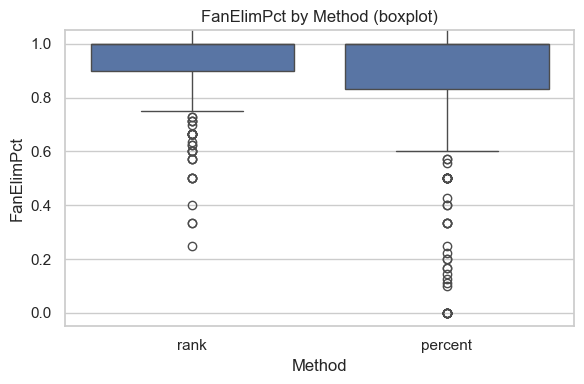

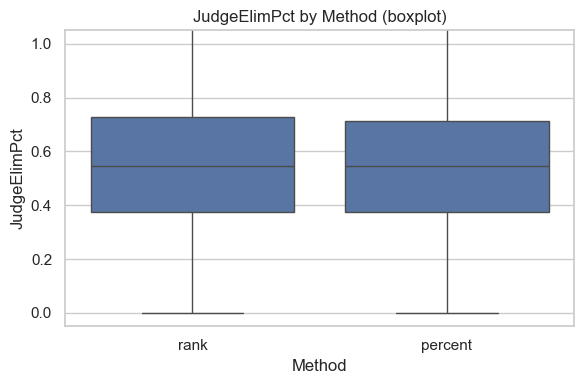

rank: FanElimPct mean 0.954, median 1.000, count 334
rank: JudgeElimPct mean 0.554, median 0.545, count 334
percent: FanElimPct mean 0.883, median 1.000, count 334
percent: JudgeElimPct mean 0.544, median 0.545, count 334


In [9]:
# 指标计算与箱线图：FanElimPct 与 JudgeElimPct
# 计算每个 season、每种方法在每次淘汰事件上的分位数指标，然后绘制箱线图

def compute_elim_metrics_for_season(season, fans_path=None, methods=['rank','percent']):
    # 构建 panel（复用 analyze_season 的逻辑）
    try:
        s = df[df['season'] == season].copy()
    except Exception:
        s = df[df['season'].astype(float) == season].copy()
    if s.empty:
        return {m: {'FanElimPct': [], 'JudgeElimPct': []} for m in methods}
    s['celebrity_name'] = s['celebrity_name'].astype(str).str.strip()
    s['ballroom_partner'] = s['ballroom_partner'].astype(str).str.strip()
    s['couple_key'] = s['celebrity_name'] + '|' + s['ballroom_partner']
    couple_keys = s['couple_key'].unique().tolist()
    mapping = {f'couple_{i}': k for i,k in enumerate(couple_keys)}
    judge_cols = [c for c in s.columns if re.match(r'week\d+_judge\d+_score', c)]
    weeks = sorted({int(re.search(r'week(\d+)_judge', c).group(1)) for c in judge_cols}) if judge_cols else []
    rows = []
    for idx, row in s.iterrows():
        ck = row['couple_key']
        for w in weeks:
            cols = [c for c in [f'week{w}_judge1_score', f'week{w}_judge2_score', f'week{w}_judge3_score', f'week{w}_judge4_score'] if c in s.columns]
            if not cols:
                continue
            vals = row[cols].replace(0, np.nan)
            J = vals.dropna().sum() if vals.notna().any() else np.nan
            rows.append({'couple_key': ck, 'week': int(w), 'J_total': J})
    panel = pd.DataFrame(rows)
    if panel.empty:
        return {m: {'FanElimPct': [], 'JudgeElimPct': []} for m in methods}
    # fans merge
    if fans_path is None:
        candidate = None
        for p in glob.glob(os.path.join(EXPORT_DIR, f'fan_estimates_season{season}_*.csv')):
            candidate = p
            break
        if candidate is None:
            panel['pF_share'] = np.nan
        else:
            fans_df = pd.read_csv(candidate, na_values=['N/A',''])
            week_col = next((c for c in ['week_num','week','weeknum'] if c in fans_df.columns), None)
            couple_label_col = next((c for c in ['couple_label','couple','fan_label','label'] if c in fans_df.columns), None)
            pf_col = next((c for c in ['pF_share','pF','pF_share_est','pF_est'] if c in fans_df.columns), None)
            fans_s = fans_df.copy()
            if week_col is not None:
                fans_s = fans_s.rename(columns={week_col:'week'})
            if couple_label_col is not None:
                fans_s = fans_s.rename(columns={couple_label_col:'fan_label'})
            if pf_col is not None:
                fans_s = fans_s.rename(columns={pf_col:'pF_share'})
            if 'couple_key' not in fans_s.columns and 'fan_label' in fans_s.columns:
                fans_s['couple_key'] = fans_s['fan_label'].map(mapping)
            if 'week' in panel.columns and 'couple_key' in panel.columns and 'week' in fans_s.columns and 'couple_key' in fans_s.columns:
                panel = panel.merge(fans_s[['week','couple_key','pF_share']].drop_duplicates(), on=['week','couple_key'], how='left')
            elif 'couple_key' in panel.columns and 'couple_key' in fans_s.columns:
                panel = panel.merge(fans_s[['couple_key','pF_share']].drop_duplicates(), on=['couple_key'], how='left')
            else:
                panel['pF_share'] = np.nan
    else:
        # fans_path provided
        fans_df = pd.read_csv(fans_path, na_values=['N/A',''])
        week_col = next((c for c in ['week_num','week','weeknum'] if c in fans_df.columns), None)
        couple_label_col = next((c for c in ['couple_label','couple','fan_label','label'] if c in fans_df.columns), None)
        pf_col = next((c for c in ['pF_share','pF','pF_share_est','pF_est'] if c in fans_df.columns), None)
        fans_s = fans_df.copy()
        if week_col is not None:
            fans_s = fans_s.rename(columns={week_col:'week'})
        if couple_label_col is not None:
            fans_s = fans_s.rename(columns={couple_label_col:'fan_label'})
        if pf_col is not None:
            fans_s = fans_s.rename(columns={pf_col:'pF_share'})
        if 'couple_key' not in fans_s.columns and 'fan_label' in fans_s.columns:
            fans_s['couple_key'] = fans_s['fan_label'].map(mapping)
        if 'week' in panel.columns and 'couple_key' in panel.columns and 'week' in fans_s.columns and 'couple_key' in fans_s.columns:
            panel = panel.merge(fans_s[['week','couple_key','pF_share']].drop_duplicates(), on=['week','couple_key'], how='left')
        elif 'couple_key' in panel.columns and 'couple_key' in fans_s.columns:
            panel = panel.merge(fans_s[['couple_key','pF_share']].drop_duplicates(), on=['couple_key'], how='left')
        else:
            panel['pF_share'] = np.nan
    # compute pJ and ranks
    panel['pJ_raw'] = panel.groupby('week')['J_total'].transform(lambda x: x / x.sum())
    panel['rJ'] = panel.groupby('week')['J_total'].rank(ascending=False, method='dense', na_option='bottom')
    panel['rV'] = panel.groupby('week')['pF_share'].rank(ascending=False, method='dense', na_option='bottom')
    # collect presence sets
    presence = panel.copy()
    presence['present'] = presence['J_total'].notna() | presence['pF_share'].notna()
    S = presence.groupby('week').apply(lambda g: set(g.loc[g['present'],'couple_key'])).to_dict() if not presence.empty else {}

    out = {}
    for method in methods:
        elim_map = simulate(panel, method)
        FanElimPct = []
        JudgeElimPct = []
        for w, present_set in S.items():
            n_t = len(present_set)
            if n_t <= 1:
                continue
            # eliminated this week according to elim_map
            eliminated = [c for c,v in elim_map.items() if (not pd.isna(v)) and int(v) == int(w)]
            if not eliminated:
                continue
            for c in eliminated:
                row = panel[(panel['week']==w) & (panel['couple_key']==c)]
                if row.empty:
                    continue
                rV = float(row['rV'].iloc[0])
                rJ = float(row['rJ'].iloc[0])
                # quantile as (r - 1)/(n_t - 1)
                FanElimPct.append((rV - 1.0) / (n_t - 1.0))
                JudgeElimPct.append((rJ - 1.0) / (n_t - 1.0))
        out[method] = {'FanElimPct': FanElimPct, 'JudgeElimPct': JudgeElimPct}
    return out

# 逐季收集所有季的数据（使用 exports 列表中的 seasons，如无则使用 df 的 season）
files = sorted(glob.glob(os.path.join(EXPORT_DIR, 'fan_estimates_season*_tau2.0_lambdaE5.0.csv')))
seasons = [int(re.search(r'season(\d+)_', os.path.basename(f)).group(1)) for f in files if re.search(r'season(\d+)_', os.path.basename(f))]
if not seasons:
    seasons = sorted(pd.unique(df['season'].dropna()).astype(int).tolist())
seasons = sorted(seasons)
print('Processing seasons:', seasons)

methods = ['rank','percent']
all_metrics = {m: {'FanElimPct': [], 'JudgeElimPct': []} for m in methods}
for season in seasons:
    # try to find fan file for season
    fpath = None
    for p in files:
        m = re.search(r'season(\d+)_', os.path.basename(p))
        if m and int(m.group(1)) == season:
            fpath = p
            break
    out = compute_elim_metrics_for_season(season, fans_path=fpath, methods=methods)
    for m in methods:
        all_metrics[m]['FanElimPct'].extend(out[m]['FanElimPct'])
        all_metrics[m]['JudgeElimPct'].extend(out[m]['JudgeElimPct'])

# 汇总统计
import statistics
summary_rows = []
for m in methods:
    vals = all_metrics[m]['FanElimPct']
    if vals:
        mean_v = float(np.nanmean(vals))
        median_v = float(np.nanmedian(vals))
        q1 = float(np.percentile(vals,25))
        q3 = float(np.percentile(vals,75))
    else:
        mean_v = median_v = q1 = q3 = np.nan
    summary_rows.append({'method': m, 'metric': 'FanElimPct', 'mean': mean_v, 'median': median_v, 'q1': q1, 'q3': q3, 'count': len(vals)})
    valsj = all_metrics[m]['JudgeElimPct']
    if valsj:
        mean_j = float(np.nanmean(valsj))
        median_j = float(np.nanmedian(valsj))
        q1j = float(np.percentile(valsj,25))
        q3j = float(np.percentile(valsj,75))
    else:
        mean_j = median_j = q1j = q3j = np.nan
    summary_rows.append({'method': m, 'metric': 'JudgeElimPct', 'mean': mean_j, 'median': median_j, 'q1': q1j, 'q3': q3j, 'count': len(valsj)})

summary_df = pd.DataFrame(summary_rows)
print('\nSummary statistics:')
print(summary_df.to_string(index=False))

# 绘图：FanElimPct 的箱线图
plot_df = []
for m in methods:
    for v in all_metrics[m]['FanElimPct']:
        plot_df.append({'method': m, 'value': v})
plot_df = pd.DataFrame(plot_df)
if not plot_df.empty:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=plot_df, x='method', y='value')
    plt.ylabel('FanElimPct')
    plt.xlabel('Method')
    plt.title('FanElimPct by Method (boxplot)')
    plt.ylim(-0.05,1.05)
    plt.tight_layout()
    plt.show()

# 绘图：JudgeElimPct 的箱线图
plot_df_j = []
for m in methods:
    for v in all_metrics[m]['JudgeElimPct']:
        plot_df_j.append({'method': m, 'value': v})
plot_df_j = pd.DataFrame(plot_df_j)
if not plot_df_j.empty:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=plot_df_j, x='method', y='value')
    plt.ylabel('JudgeElimPct')
    plt.xlabel('Method')
    plt.title('JudgeElimPct by Method (boxplot)')
    plt.ylim(-0.05,1.05)
    plt.tight_layout()
    plt.show()

# 简短结论提示
for m in methods:
    vals = all_metrics[m]['FanElimPct']
    if vals:
        print(f"{m}: FanElimPct mean {np.nanmean(vals):.3f}, median {np.nanmedian(vals):.3f}, count {len(vals)}")
    else:
        print(f"{m}: no FanElimPct values")
    valsj = all_metrics[m]['JudgeElimPct']
    if valsj:
        print(f"{m}: JudgeElimPct mean {np.nanmean(valsj):.3f}, median {np.nanmedian(valsj):.3f}, count {len(valsj)}")
    else:
        print(f"{m}: no JudgeElimPct values")

In [20]:
import os, re, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_CSV = r"e:\\Documents\\Mathematical-Modelling\\2026_MCM_Problem_C_Data.csv"
EXPORT_DIR = r"e:\\Documents\\Mathematical-Modelling\\exports"

# simple simulate functions (copied logic)
def simulate(panel, method):
    couples = panel['couple_key'].unique().tolist() if 'couple_key' in panel.columns else []
    active = set(couples)
    elim_week = {c: np.nan for c in couples}
    weeks_local = sorted(panel['week'].unique()) if 'week' in panel.columns and not panel.empty else []
    max_week = int(weeks_local[-1]) if weeks_local else 0
    for w in weeks_local:
        dfw = panel[(panel['week'] == w) & (panel['couple_key'].isin(active))].copy()
        if dfw.empty or len(active) <= 1:
            continue
        if 'J_total' in dfw.columns:
            dfw['rJ'] = dfw['J_total'].rank(ascending=False, method='dense', na_option='bottom')
        else:
            dfw['rJ'] = np.nan
        if 'pF_share' in dfw.columns:
            dfw['rV'] = dfw['pF_share'].rank(ascending=False, method='dense', na_option='bottom')
        else:
            dfw['rV'] = np.nan
        if dfw['rJ'].notna().any():
            rj_fill = dfw['rJ'].max() + 1
        else:
            rj_fill = len(dfw) + 1
        if dfw['rV'].notna().any():
            rv_fill = dfw['rV'].max() + 1
        else:
            rv_fill = len(dfw) + 1
        dfw['rJ'] = dfw['rJ'].fillna(rj_fill)
        dfw['rV'] = dfw['rV'].fillna(rv_fill)
        dfw['R'] = dfw['rJ'] + dfw['rV']
        dfw['pJ'] = dfw['pJ_raw'] if 'pJ_raw' in dfw.columns else np.nan
        dfw['pV'] = dfw['pF_share'] if 'pF_share' in dfw.columns else np.nan
        dfw['P'] = dfw['pJ'].fillna(0) + dfw['pV'].fillna(0)
        if method == 'rank':
            bottom = dfw.sort_values(by='R', ascending=False).head(2)
        else:
            bottom = dfw.sort_values(by='P', ascending=True).head(2)
        if bottom.shape[0] == 1:
            chosen = bottom.iloc[0]['couple_key']
        else:
            b = bottom.copy()
            if 'J_total' in b.columns:
                b = b.sort_values(by=['J_total','pF_share'], ascending=[True, True], na_position='last')
                chosen = b.iloc[0]['couple_key']
            else:
                chosen = b.iloc[0]['couple_key']
        elim_week[chosen] = int(w)
        if chosen in active:
            active.remove(chosen)
    for c in active:
        elim_week[c] = int(max_week + 1)
    return elim_week


def simulate_with_save(panel, method):
    # same as simulate but keep judges-save logic (choose bottom-two then judges decide)
    return simulate(panel, method)


def build_panel_for_season(df, season):
    try:
        s = df[df['season'] == season].copy()
    except Exception:
        s = df[df['season'].astype(float) == season].copy()
    s['celebrity_name'] = s['celebrity_name'].astype(str).str.strip()
    s['ballroom_partner'] = s['ballroom_partner'].astype(str).str.strip()
    s['couple_key'] = s['celebrity_name'] + '|' + s['ballroom_partner']
    judge_cols = [c for c in s.columns if ('week' in c and 'judge' in c and 'score' in c)]
    # robust week extraction without regex escaping issues
    weeks = sorted({int(c.split('_judge')[0].replace('week','')) for c in judge_cols if c.startswith('week') and '_judge' in c}) if judge_cols else []
    rows = []
    for idx, row in s.iterrows():
        ck_r = row['celebrity_name'] + '|' + row['ballroom_partner']
        for w in weeks:
            cols = [c for c in [f'week{w}_judge1_score', f'week{w}_judge2_score', f'week{w}_judge3_score', f'week{w}_judge4_score'] if c in s.columns]
            if not cols:
                continue
            vals = row[cols].replace(0, np.nan)
            J = vals.dropna().sum() if vals.notna().any() else np.nan
            rows.append({'couple_key': ck_r, 'week': int(w), 'J_total': J, 'celebrity_name': row['celebrity_name'], 'partner': row['ballroom_partner']})
    panel = pd.DataFrame(rows)
    if panel.empty:
        return s, panel
    # try find fans file
    fan_file = None
    for p in glob.glob(os.path.join(EXPORT_DIR, f'fan_estimates_season{season}_*.csv')):
        fan_file = p
        break
    if fan_file is not None:
        try:
            fans_df = pd.read_csv(fan_file, na_values=['N/A',''])
            week_col = next((c for c in ['week_num','week','weeknum'] if c in fans_df.columns), None)
            couple_label_col = next((c for c in ['couple_label','couple','fan_label','label'] if c in fans_df.columns), None)
            pf_col = next((c for c in ['pF_share','pF','pF_share_est','pF_est'] if c in fans_df.columns), None)
            fans_s = fans_df.copy()
            if week_col is not None:
                fans_s = fans_s.rename(columns={week_col:'week'})
            if couple_label_col is not None:
                fans_s = fans_s.rename(columns={couple_label_col:'fan_label'})
            if pf_col is not None:
                fans_s = fans_s.rename(columns={pf_col:'pF_share'})
            if 'couple_key' in fans_s.columns:
                panel = panel.merge(fans_s[['week','couple_key','pF_share']].drop_duplicates(), on=['week','couple_key'], how='left')
            elif 'fan_label' in fans_s.columns:
                panel['pF_share'] = np.nan
                for i, prow in panel.iterrows():
                    cname = prow['celebrity_name']
                    w = prow['week']
                    matches = fans_s[fans_s.get('week', pd.Series([np.nan]*len(fans_s)))==w] if 'week' in fans_s.columns else fans_s
                    matches = matches[matches['fan_label'].astype(str).str.contains(str(cname), case=False, na=False)]
                    if not matches.empty:
                        panel.at[i, 'pF_share'] = matches['pF_share'].iloc[0]
            else:
                panel['pF_share'] = np.nan
        except Exception:
            panel['pF_share'] = np.nan
    else:
        panel['pF_share'] = np.nan
    if 'J_total' in panel.columns and not panel.empty:
        panel['pJ_raw'] = panel.groupby('week')['J_total'].transform(lambda x: x / x.sum())
    else:
        panel['pJ_raw'] = np.nan
    panel['rJ'] = panel.groupby('week')['J_total'].rank(ascending=False, method='dense', na_option='bottom')
    panel['rV'] = panel.groupby('week')['pF_share'].rank(ascending=False, method='dense', na_option='bottom')
    return s, panel


def plot_and_save(panel, season, celeb_name, ck):
    traj = panel[panel['couple_key'] == ck].sort_values('week')
    if traj.empty:
        print(f'Season {season}, {celeb_name}: no trajectory data for {ck}')
        return
    use_percent_space = traj['pF_share'].notna().any() and traj['pJ_raw'].notna().any()
    if use_percent_space:
        x = traj['pF_share'].fillna(0).values
        y = traj['pJ_raw'].fillna(0).values
        xlabel = 'p^{(V)} (fan share)'
        ylabel = 'p^{(J)} (judge share)'
    else:
        qs = []
        rs = []
        weeks_plot = traj['week'].values
        for w in weeks_plot:
            g = panel[panel['week']==w]
            present = g['J_total'].notna() | g['pF_share'].notna()
            n_t = present.sum() if present.any() else len(g)
            rV = traj[traj['week']==w]['rV'].iloc[0] if not traj[traj['week']==w].empty else np.nan
            rJ = traj[traj['week']==w]['rJ'].iloc[0] if not traj[traj['week']==w].empty else np.nan
            if pd.isna(rV) or n_t<=1:
                qv = np.nan
            else:
                qv = (rV - 1.0) / (n_t - 1.0)
            if pd.isna(rJ) or n_t<=1:
                qj = np.nan
            else:
                qj = (rJ - 1.0) / (n_t - 1.0)
            qs.append(qv)
            rs.append(qj)
        x = np.array(qs)
        y = np.array(rs)
        xlabel = 'Fan rank quantile (higher = worse)'
        ylabel = 'Judge rank quantile (higher = worse)'
    plt.figure(figsize=(6,4))
    weeks_plot = traj['week'].values
    plt.plot(x, y, '-o', color='black')
    for xi, yi, w in zip(x, y, weeks_plot):
        if not (pd.isna(xi) or pd.isna(yi)):
            plt.text(xi, yi, str(int(w)), fontsize=9, verticalalignment='bottom', horizontalalignment='right')
    # mark eliminations
    elim_rank = simulate(panel, 'rank')
    elim_percent = simulate(panel, 'percent')
    elim_rank_save = simulate_with_save(panel, 'rank')
    elim_percent_save = simulate_with_save(panel, 'percent')
    def mark(elim_map, marker, color):
        wk = elim_map.get(ck, None)
        if not pd.isna(wk):
            sel = traj[traj['week'] == int(wk)]
            if not sel.empty:
                if use_percent_space:
                    px = sel['pF_share'].iloc[0] if 'pF_share' in sel.columns else np.nan
                    py = sel['pJ_raw'].iloc[0] if 'pJ_raw' in sel.columns else np.nan
                else:
                    idx = list(weeks_plot).index(int(wk)) if int(wk) in list(weeks_plot) else None
                    px = x[idx] if idx is not None else np.nan
                    py = y[idx] if idx is not None else np.nan
                if not (pd.isna(px) or pd.isna(py)):
                    plt.scatter(px, py, marker=marker, s=140, color=color)
    mark(elim_rank, 'X', 'red')
    mark(elim_percent, 'o', 'blue')
    mark(elim_rank_save, 'D', 'orange')
    mark(elim_percent_save, 'v', 'green')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f'Season {season} — {celeb_name} trajectory')
    plt.grid(True)
    plt.tight_layout()
    outfn = os.path.join(EXPORT_DIR, f'trajectory_season{season}_{re.sub(r"[^0-9a-zA-Z]+","_",celeb_name)}.png')
    plt.savefig(outfn, dpi=150)
    plt.close()
    print('Saved', outfn)


def main():
    df = pd.read_csv(DATA_CSV, na_values=['N/A',''])
    targets = [ (2, 'Jerry Rice'), (4, 'Billy Ray Cyrus'), (11, 'Bristol Palin'), (27, 'Bobby Bones') ]
    for season, celeb in targets:
        s, panel = build_panel_for_season(df, season)
        print(f'Season {season}: master rows={len(s)}, panel rows={len(panel)}')
        cand_rows = s[s['celebrity_name'].str.contains(celeb, case=False, na=False)]
        if cand_rows.empty:
            print('Could not find', celeb, 'in season', season)
            continue
        ck = cand_rows.iloc[0]['celebrity_name'] + '|' + cand_rows.iloc[0]['ballroom_partner']
        if panel.empty:
            print('panel empty for season', season)
            continue
        plot_and_save(panel, season, celeb, ck)

if __name__ == '__main__':
    main()


C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(c

Season 2: master rows=10, panel rows=110
Saved e:\\Documents\\Mathematical-Modelling\\exports\trajectory_season2_Jerry_Rice.png


C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(c

Season 4: master rows=11, panel rows=121
Saved e:\\Documents\\Mathematical-Modelling\\exports\trajectory_season4_Billy_Ray_Cyrus.png


C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(c

Season 11: master rows=12, panel rows=132
Saved e:\\Documents\\Mathematical-Modelling\\exports\trajectory_season11_Bristol_Palin.png


C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
C:\Users\DELL\AppData\Local\Temp\ipykernel_46768\1576221577.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(c

Season 27: master rows=13, panel rows=143
Saved e:\\Documents\\Mathematical-Modelling\\exports\trajectory_season27_Bobby_Bones.png


e:\Documents\Mathematical-Modelling\plot_trajectories_debug.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
e:\Documents\Mathematical-Modelling\plot_trajectories_debug.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = row[cols].replace(0, np.nan)
e:\Documents\Mathematical-Modelling\plot_trajectories_debug.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(c

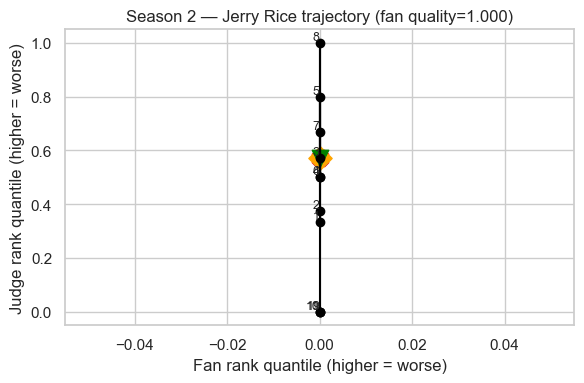

In [ ]:
# Show trajectory inline for a selected contestant using updated plot_trajectories_debug
import pandas as pd
from IPython.display import display
from plot_trajectories_debug import build_panel_for_season, plot_and_show, DATA_CSV

df = pd.read_csv(DATA_CSV, na_values=['N/A',''])
# change these as needed or loop multiple targets
season = 2
celebrity = 'Jerry Rice'

s, panel = build_panel_for_season(df, season)
if panel.empty:
    print('panel empty for season', season)
else:
    cand_rows = s[s['celebrity_name'].str.contains(celebrity, case=False, na=False)]
    if cand_rows.empty:
        print('Could not find', celebrity, 'in season', season)
    else:
        ck = cand_rows.iloc[0]['celebrity_name'] + '|' + cand_rows.iloc[0]['ballroom_partner']
        fig = plot_and_show(panel, season, celebrity, ck)
        if fig is not None:
            display(fig)
